In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import os

In [48]:
bikes_df = pd.read_csv("./bikes/day.csv")
bikes_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


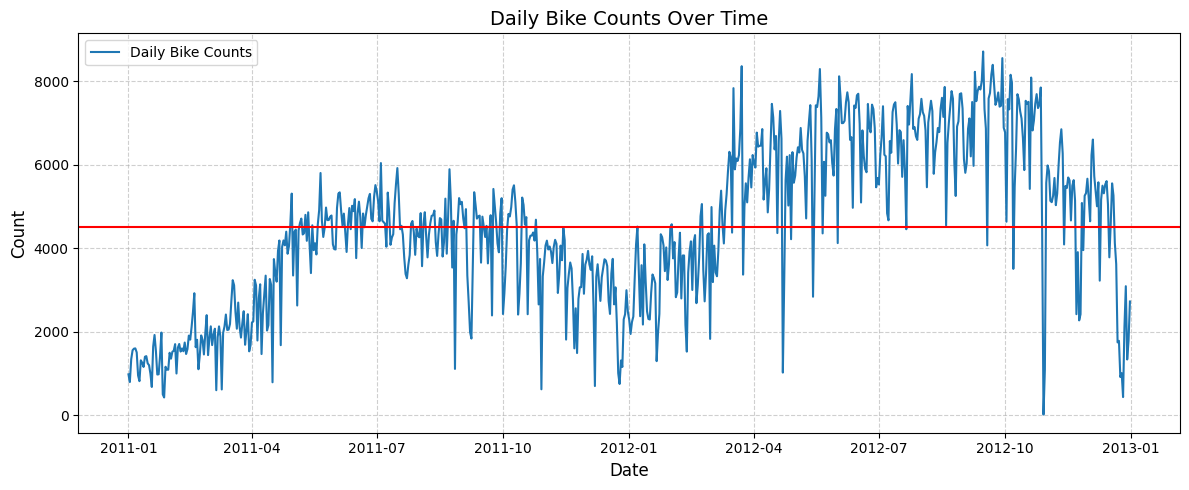

In [49]:
bikes_df["date"] = pd.to_datetime(bikes_df["dteday"])
df1 = bikes_df.sort_values("date", inplace=False)
plt.figure(figsize=(12, 5))
plt.plot(
    df1['date'],
    df1['cnt'],
    color='tab:blue',
    linewidth=1.5,
    label='Daily Bike Counts',
)

plt.axhline(df1["cnt"].mean(),color="red")

plt.title('Daily Bike Counts Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

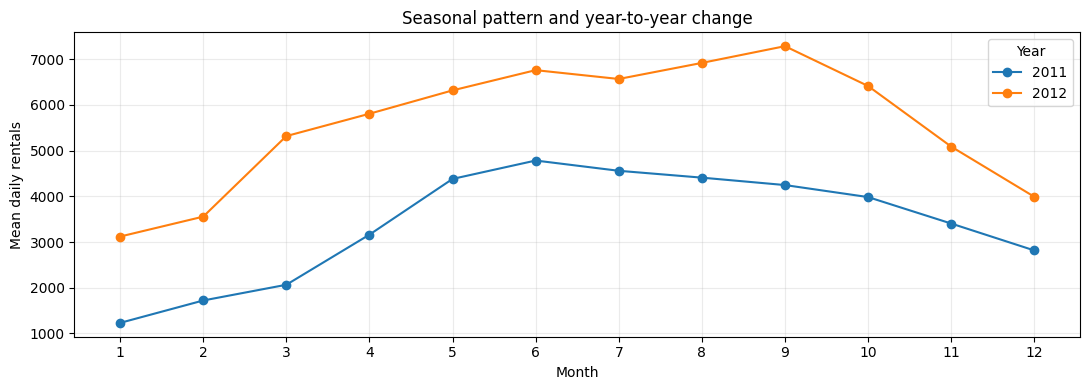

In [ ]:
monthly_means = df1.groupby([df1['date'].dt.year, 'mnth'])['cnt'].mean().unstack(0)
ax = monthly_means.plot(marker='o', figsize=(11, 4))
ax.set(title='Seasonal pattern and year-to-year change', xlabel='Month',
       ylabel='Mean daily rentals', xticks=range(1, 13))
ax.legend(title='Year')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Exploratory analysis of raw bike counts

`casual` and `registered` are excluded from predictor plots because their sum is `cnt`
using their target-day values to predict `cnt` would leak the answer.

In [51]:
import numpy as np
from IPython.display import display

eda = df1.copy().sort_values('date').set_index('date')
assert eda.index.is_unique, 'Resolve duplicate dates before time-series diagnostics.'
assert eda.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all(), 'Check daily gaps.'
eda['year'] = eda.index.year
eda['quarter'] = eda.index.to_period('Q').astype(str)
display(eda.groupby('year')['cnt'].agg(['count', 'mean', 'std', 'min', 'max']).round(1))

,count,mean,std,min,max
year,,,,,
2011,365,3405.8,1378.8,431,6043
2012,366,5599.9,1788.7,22,8714


Clearly a year-to-year non-stationarity

### Continuous features and the target
Color separates the years so that changes in demand level are visible at similar feature values.


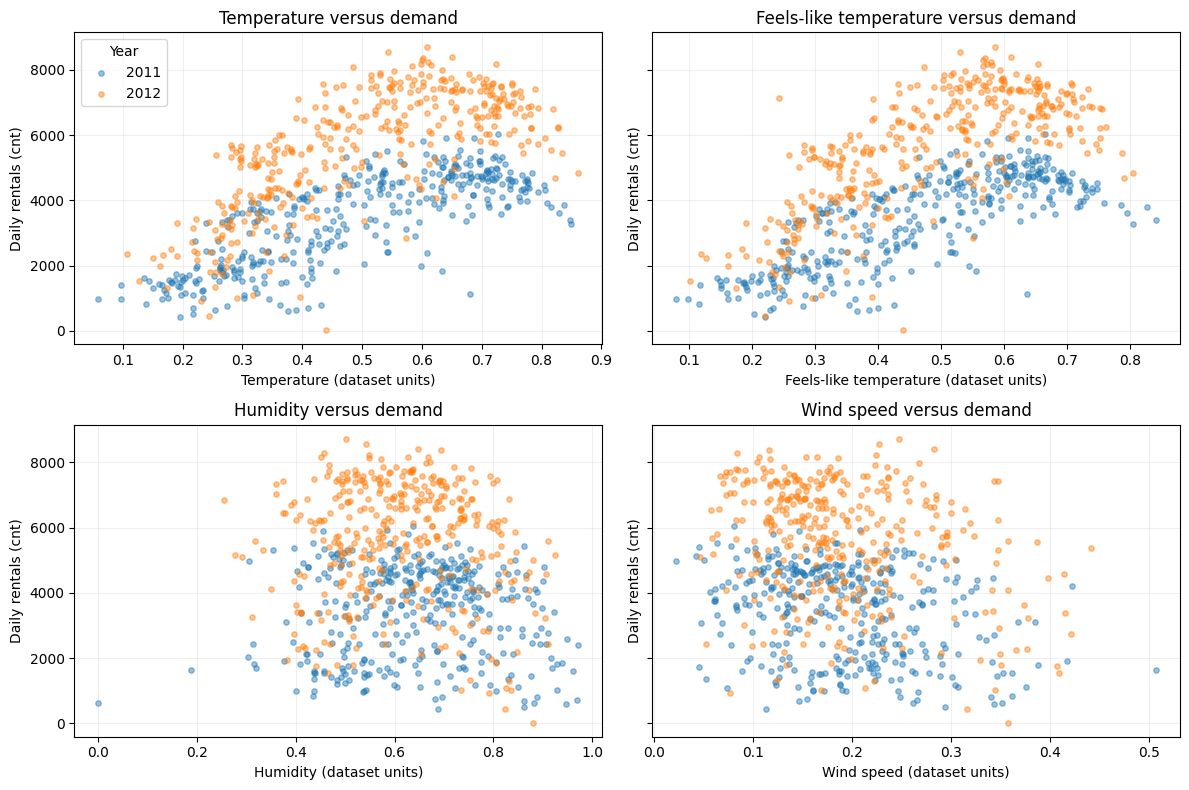

In [52]:
features = {'temp': 'Temperature', 'atemp': 'Feels-like temperature',
            'hum': 'Humidity', 'windspeed': 'Wind speed'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, (feature, label) in zip(axes.flat, features.items()):
    for year, group in eda.groupby('year'):
        ax.scatter(group[feature], group['cnt'], s=15, alpha=0.45, label=str(year))
    ax.set(xlabel=f'{label} (dataset units)', ylabel='Daily rentals (cnt)',
           title=f'{label} versus demand')
    ax.grid(alpha=0.2)
axes[0, 0].legend(title='Year')
fig.tight_layout()
plt.show()

Upon initial visual analysis:
- Higher temperature yields higher count, but non-stationary - changes with year (same for feels like temp)
- Generally no clear relationship between humidity and demand
- Weak relationship between windspeed and demand -> higher windspeed decreases demand

### Distribution changes through time


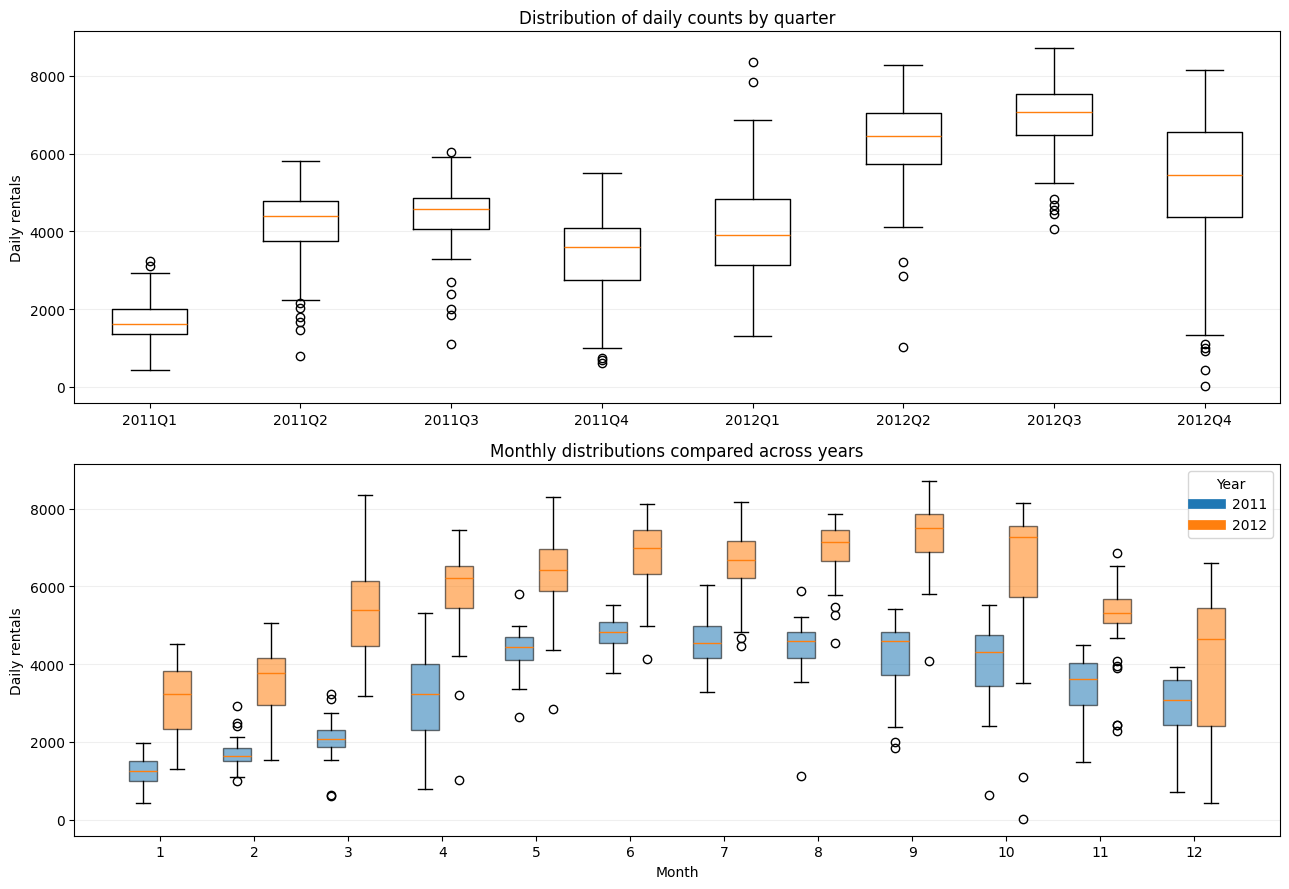

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
quarters = sorted(eda['quarter'].unique())
axes[0].boxplot([eda.loc[eda['quarter'].eq(q), 'cnt'] for q in quarters])
axes[0].set_xticks(range(1, len(quarters) + 1), quarters)
axes[0].set(title='Distribution of daily counts by quarter', ylabel='Daily rentals')
for year, offset, color in [(2011, -0.18, 'tab:blue'), (2012, 0.18, 'tab:orange')]:
    groups = [eda.loc[eda['year'].eq(year) & eda['mnth'].eq(m), 'cnt'] for m in range(1, 13)]
    boxes = axes[1].boxplot(groups, positions=np.arange(1, 13) + offset,
                            widths=0.30, patch_artist=True, manage_ticks=False)
    for box in boxes['boxes']:
        box.set(facecolor=color, alpha=0.55)
    axes[1].plot([], [], color=color, linewidth=7, label=str(year))
axes[1].set(xticks=range(1, 13), xlabel='Month', ylabel='Daily rentals',
            title='Monthly distributions compared across years')
axes[1].legend(title='Year')
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

### Raw counts versus changes in counts
First differences are **cnt(t) − cnt(t−1)**: positive values mean more rentals than yesterday

Seven-day differences are **cnt(t) − cnt(t−7)**: changes relative to the same weekday last week

Both are shown on their actual dates without filling the initially undefined differences.


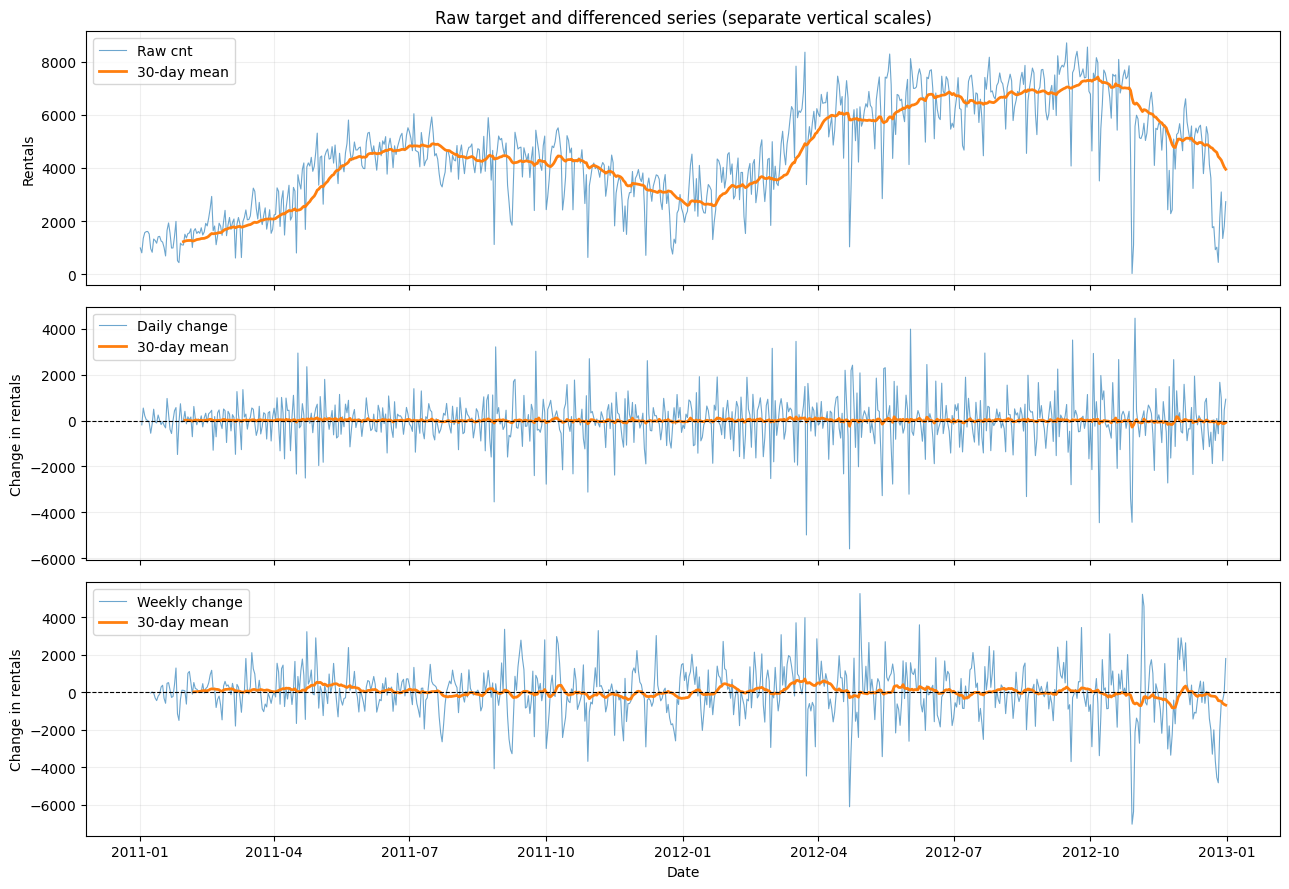

In [54]:
diagnostics = pd.DataFrame({'Raw cnt': eda['cnt'],
                            'Daily change': eda['cnt'].diff(),
                            'Weekly change': eda['cnt'].diff(7)})
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, column in zip(axes, diagnostics):
    series = diagnostics[column]
    ax.plot(series.index, series, linewidth=0.8, alpha=0.65, label=column)
    ax.plot(series.index, series.rolling(30, min_periods=30).mean(),
            color='tab:orange', linewidth=2, label='30-day mean')
    if column != 'Raw cnt':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Rentals' if column == 'Raw cnt' else 'Change in rentals')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.2)
axes[0].set_title('Raw target and differenced series (separate vertical scales)')
axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.show()

### Interpreting stationarity
The raw target shows annual seasonality and a higher level in 2012 than in 2011.
This supports treating it as non-stationary in mean. Weak stationarity requires a constant
mean 

differencing need not remove all seasonal or variance changes

Only two annual cycles are available, limiting conclusions about long-term seasonal stability

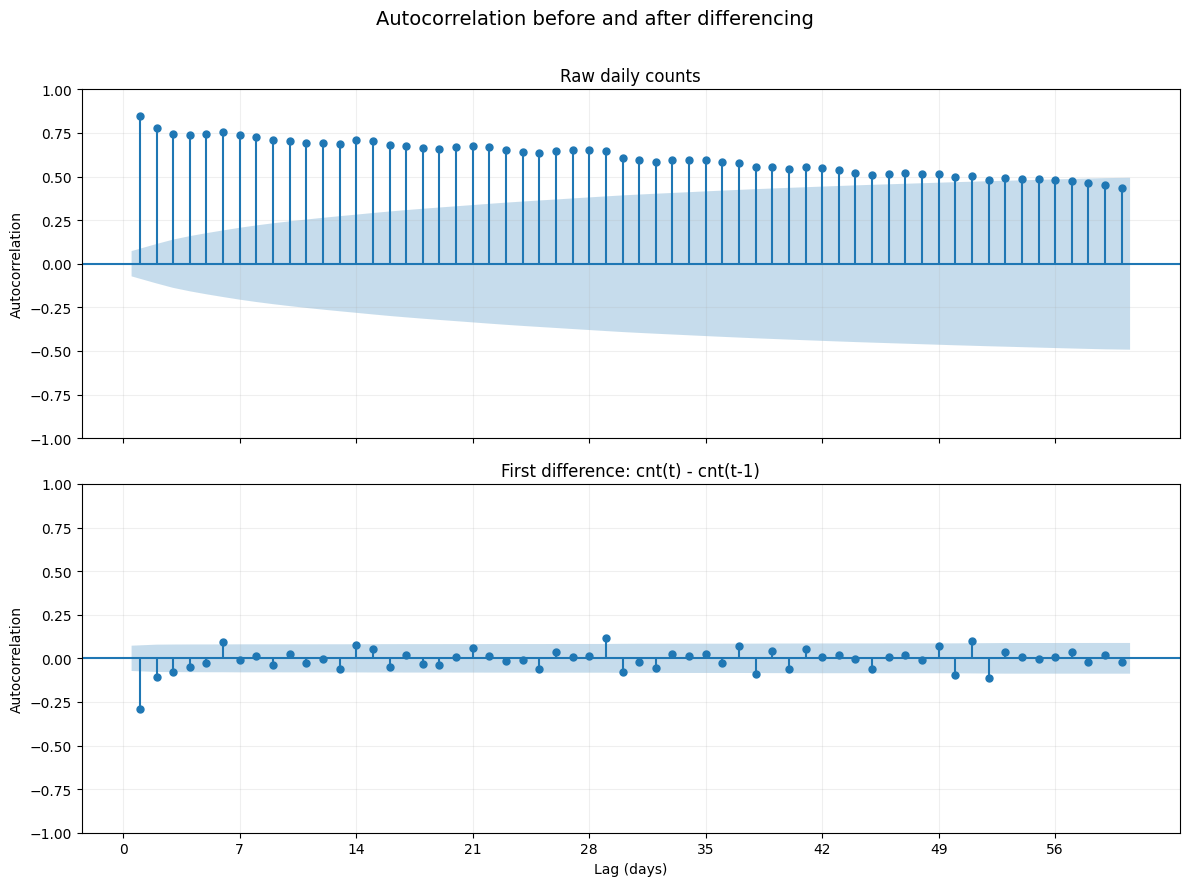

In [56]:
from statsmodels.graphics.tsaplots import plot_acf

acf_counts = bikes_df.sort_values('date').set_index('date')['cnt']
acf_series = {
    'Raw daily counts': acf_counts,
    'First difference: cnt(t) - cnt(t-1)': acf_counts.diff().dropna(),
}
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for ax, (label, series) in zip(axes, acf_series.items()):
    plot_acf(series, lags=60, zero=False, alpha=0.05, ax=ax, title=label)
    ax.set(ylabel='Autocorrelation', ylim=(-1, 1), xticks=range(0, 61, 7))
    ax.grid(alpha=0.2)
axes[-1].set_xlabel('Lag (days)')
fig.suptitle('Autocorrelation before and after differencing', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


Autocorrelation measures sequential correlation between cnt values in lag (time) steps apart. Values close to 1 or -1 suggest positively or negatively drifting target values (t timesteps apart) in time. So, slowly decaying AC values as seen in original cnt plot, suggests strong memory and positive drift between values. The flat values in the difference plot suggests that temporal differences are not correlated and that distribution is tempoerally staionary. For top plot also most autocorrelation values, at many lags, is statistically significant, since in 5 percentile under null hypothesis that it is actually 0. 